# Notebook 4: Build Canada Basemap Grids

## Objectives

This notebook builds Canada-wide basemap grids for spatial aggregation.

The basemap regions will serve as the common spatial indexing layer for later aggregation of roads, infrastructure, industrial facilities, resource potentials, and demand data.

This notebook focuses only on basemap generation and validation. It does not perform graph construction, connectivity analysis, or TEMOA SQL encoding.

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Point
from tqdm.auto import tqdm


# Define input and output directories.

RAW_BASEMAP = Path("../data_files/raw/basemaps")
PROCESSED_BASEMAP = Path("../data_files/processed/basemaps")

PROCESSED_BASEMAP.mkdir(
    parents=True,
    exist_ok=True,
)


# Coordinate reference systems.

WGS84_CRS = "EPSG:4326"
CANADA_PROJECTED_CRS = "EPSG:3347"

In [2]:
# Locate the raw province and territory boundary shapefile.

boundary_shapefiles = sorted(
    RAW_BASEMAP.glob("*.shp")
)

if len(boundary_shapefiles) != 1:
    raise ValueError(
        f"Expected exactly one boundary shapefile in {RAW_BASEMAP}, "
        f"found {len(boundary_shapefiles)}: "
        f"{[path.name for path in boundary_shapefiles]}"
    )

province_boundary_path = boundary_shapefiles[0]

print(f"Using boundary file: {province_boundary_path.name}")

Using boundary file: lpr_000b21a_e.shp


In [3]:
# Load the Canada province and territory cartographic boundary file.

provinces = gpd.read_file(
    province_boundary_path
)

provinces.head()

,PRUID,DGUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR,LANDAREA,geometry
0,10,2021A000210,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.,3.581704e+05,"MULTIPOLYGON (((8841194.729 2213093.663, 88411..."
1,11,2021A000211,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.,5.681179e+03,"MULTIPOLYGON (((8374335.443 1629502.597, 83743..."
2,12,2021A000212,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.,5.282471e+04,"MULTIPOLYGON (((8310463.217 1250722.263, 83104..."
3,13,2021A000213,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.,7.124850e+04,"MULTIPOLYGON (((7964100.72 1576822.289, 796410..."
4,24,2021A000224,Quebec / Québec,Quebec,Québec,Que.,Qc,1.298600e+06,"MULTIPOLYGON (((6948393.211 2760814.626, 69483..."


In [4]:
# Inspect the loaded boundary file.

print(provinces.crs)
print(provinces.shape)
print(provinces.columns.tolist())

provinces.head()

EPSG:3347
(13, 9)
['PRUID', 'DGUID', 'PRNAME', 'PRENAME', 'PRFNAME', 'PREABBR', 'PRFABBR', 'LANDAREA', 'geometry']


,PRUID,DGUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR,LANDAREA,geometry
0,10,2021A000210,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.,3.581704e+05,"MULTIPOLYGON (((8841194.729 2213093.663, 88411..."
1,11,2021A000211,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.,5.681179e+03,"MULTIPOLYGON (((8374335.443 1629502.597, 83743..."
2,12,2021A000212,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.,5.282471e+04,"MULTIPOLYGON (((8310463.217 1250722.263, 83104..."
3,13,2021A000213,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.,7.124850e+04,"MULTIPOLYGON (((7964100.72 1576822.289, 796410..."
4,24,2021A000224,Quebec / Québec,Quebec,Québec,Que.,Qc,1.298600e+06,"MULTIPOLYGON (((6948393.211 2760814.626, 69483..."


In [5]:
# Inspect province and territory identifiers.

provinces[
    [
        column
        for column in provinces.columns
        if "PR" in column.upper() or "NAME" in column.upper()
    ]
].head()

,PRUID,PRNAME,PRENAME,PRFNAME,PREABBR,PRFABBR
0,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,Newfoundland and Labrador,Terre-Neuve-et-Labrador,N.L.,T.-N.-L.
1,11,Prince Edward Island / Île-du-Prince-Édouard,Prince Edward Island,Île-du-Prince-Édouard,P.E.I.,Î.-P.-É.
2,12,Nova Scotia / Nouvelle-Écosse,Nova Scotia,Nouvelle-Écosse,N.S.,N.-É.
3,13,New Brunswick / Nouveau-Brunswick,New Brunswick,Nouveau-Brunswick,N.B.,N.-B.
4,24,Quebec / Québec,Quebec,Québec,Que.,Qc


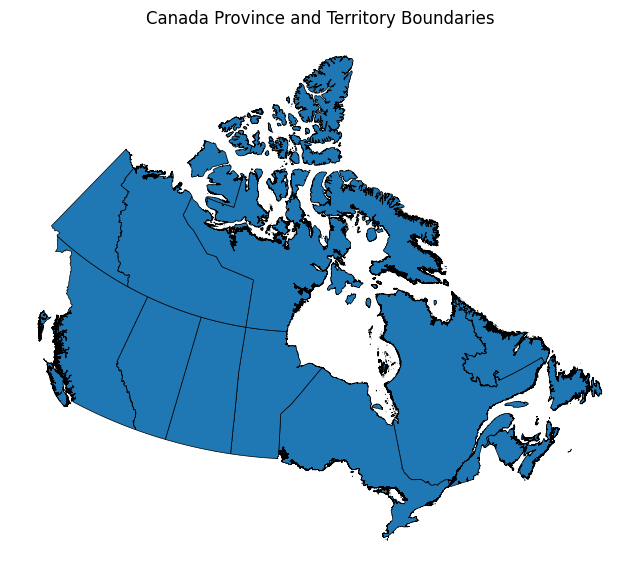

In [6]:
# Plot the province and territory boundary file.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

provinces.plot(
    ax=ax,
    linewidth=0.5,
    edgecolor="black",
)

ax.set_title("Canada Province and Territory Boundaries")
ax.set_axis_off()

plt.show()

In [7]:
# Reproject province and territory boundaries to WGS84.

provinces_wgs84 = provinces.to_crs(
    WGS84_CRS
)

print(provinces_wgs84.crs)

EPSG:4326


In [8]:
# Dissolve province and territory boundaries into a single Canada polygon.
# Construct a single Canada land boundary.

print("Building Canada boundary...")

canada_geometry = (
    provinces_wgs84.geometry
    .union_all()
)

canada_boundary = gpd.GeoDataFrame(
    {
        "name": ["Canada"],
    },
    geometry=[canada_geometry],
    crs=WGS84_CRS,
)

print("Canada boundary constructed.")

canada_boundary

Building Canada boundary...
Canada boundary constructed.


,name,geometry
0,Canada,"MULTIPOLYGON (((-132.53304 53.04474, -132.5330..."


In [9]:
# Extract Canada geometry for repeated spatial operations.

canada_geometry = canada_boundary.geometry.iloc[0]

print("Canada geometry ready.")

Canada geometry ready.


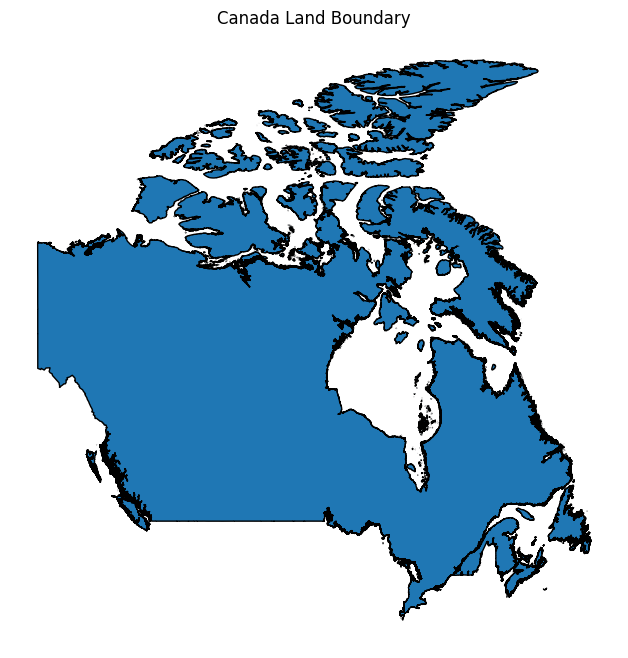

In [10]:
# Plot the dissolved Canada boundary.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

canada_boundary.plot(
    ax=ax,
    edgecolor="black",
)

ax.set_title(
    "Canada Land Boundary"
)

ax.set_axis_off()

plt.show()

In [11]:
# Define latitude/longitude basemap resolutions.

BASEMAP_RESOLUTIONS = [
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
]

In [12]:
# Build a regular latitude/longitude basemap grid.

def build_latlon_grid(
    boundary_geometry,
    boundary_gdf: gpd.GeoDataFrame,
    resolution_deg: float,
    keep_method: str = "centroid",
) -> gpd.GeoDataFrame:
    """
    Build a regular latitude/longitude grid over a boundary polygon.
    """

    min_lon, min_lat, max_lon, max_lat = boundary_geometry.bounds

    lon_values = np.arange(
        np.floor(min_lon),
        np.ceil(max_lon),
        resolution_deg,
    )

    lat_values = np.arange(
        np.floor(min_lat),
        np.ceil(max_lat),
        resolution_deg,
    )

    total_cells = len(lon_values) * len(lat_values)

    print(
        f"\nBuilding {resolution_deg:g}° grid "
        f"using '{keep_method}' retention..."
    )
    print(f"Candidate cells: {total_cells:,}")

    grid_cells = []

    progress = tqdm(
        total=total_cells,
        desc=f"{resolution_deg:g}° {keep_method}",
        unit="cells",
    )

    for lon_min in lon_values:
        for lat_min in lat_values:

            lon_center = round(
                lon_min + resolution_deg / 2,
                6,
            )
            lat_center = round(
                lat_min + resolution_deg / 2,
                6,
            )

            grid_cells.append(
                {
                    "lon_min": round(lon_min, 6),
                    "lon_max": round(lon_min + resolution_deg, 6),
                    "lat_min": round(lat_min, 6),
                    "lat_max": round(lat_min + resolution_deg, 6),
                    "lon": lon_center,
                    "lat": lat_center,
                    "geometry": box(
                        lon_min,
                        lat_min,
                        lon_min + resolution_deg,
                        lat_min + resolution_deg,
                    ),
                    "centroid_geometry": Point(
                        lon_center,
                        lat_center,
                    ),
                }
            )

            progress.update(1)

    progress.close()

    print("Converting candidate cells to GeoDataFrame...")

    grid = gpd.GeoDataFrame(
        grid_cells,
        geometry="geometry",
        crs=WGS84_CRS,
    )

    print("Applying Canada boundary filter using spatial join...")

    if keep_method == "centroid":

        centroid_gdf = gpd.GeoDataFrame(
            grid.drop(columns="geometry"),
            geometry=gpd.GeoSeries(
                grid["centroid_geometry"],
                crs=WGS84_CRS,
            ),
            crs=WGS84_CRS,
        )

        keep_index = gpd.sjoin(
            centroid_gdf,
            boundary_gdf,
            how="inner",
            predicate="within",
        ).index.unique()

        grid = grid.loc[
            keep_index
        ].copy()

    elif keep_method == "intersects":

        keep_index = gpd.sjoin(
            grid,
            boundary_gdf,
            how="inner",
            predicate="intersects",
        ).index.unique()

        grid = grid.loc[
            keep_index
        ].copy()

    else:
        raise ValueError(
            "keep_method must be either 'centroid' or 'intersects'."
        )

    grid = grid.drop(
        columns="centroid_geometry"
    )

    grid = grid.sort_values(
        by=[
            "lat",
            "lon",
        ]
    ).reset_index(
        drop=True
    )

    grid["region"] = [
        f"R{i}" for i in grid.index
    ]

    grid["site_id"] = grid["region"]

    grid["resolution_deg"] = resolution_deg
    grid["keep_method"] = keep_method

    print(
        f"Completed {resolution_deg:g}° {keep_method}: "
        f"{len(grid):,} retained cells.\n"
    )

    return grid

In [13]:
# Build basemaps for all resolutions and retention methods.

KEEP_METHODS = [
    "centroid",
    "intersects",
]

basemaps = {}
summary_rows = []

for resolution_deg in BASEMAP_RESOLUTIONS:
    for keep_method in KEEP_METHODS:

        basemap = build_latlon_grid(
            boundary_geometry=canada_geometry,
            boundary_gdf=canada_boundary,
            resolution_deg=resolution_deg,
            keep_method=keep_method,
        )

        key = f"{resolution_deg:g}deg_{keep_method}"
        basemaps[key] = basemap

        summary_rows.append(
            {
                "resolution_deg": resolution_deg,
                "keep_method": keep_method,
                "regions": len(basemap),
                "lon_min": basemap["lon_min"].min(),
                "lon_max": basemap["lon_max"].max(),
                "lat_min": basemap["lat_min"].min(),
                "lat_max": basemap["lat_max"].max(),
            }
        )

        print(
            f"{key}: {len(basemap):,} regions"
        )

basemap_summary = pd.DataFrame(summary_rows)
basemap_summary


Building 0.5° grid using 'centroid' retention...
Candidate cells: 15,480


0.5° centroid:   0%|          | 0/15480 [00:00<?, ?cells/s]

Converting candidate cells to GeoDataFrame...
Applying Canada boundary filter using spatial join...
Completed 0.5° centroid: 6,749 retained cells.

0.5deg_centroid: 6,749 regions

Building 0.5° grid using 'intersects' retention...
Candidate cells: 15,480


0.5° intersects:   0%|          | 0/15480 [00:00<?, ?cells/s]

Converting candidate cells to GeoDataFrame...
Applying Canada boundary filter using spatial join...
Completed 0.5° intersects: 8,257 retained cells.

0.5deg_intersects: 8,257 regions

Building 1° grid using 'centroid' retention...
Candidate cells: 3,870


...

5° centroid:   0%|          | 0/162 [00:00<?, ?cells/s]

Converting candidate cells to GeoDataFrame...
Applying Canada boundary filter using spatial join...
Completed 5° centroid: 65 retained cells.

5deg_centroid: 65 regions

Building 5° grid using 'intersects' retention...
Candidate cells: 162


5° intersects:   0%|          | 0/162 [00:00<?, ?cells/s]

Converting candidate cells to GeoDataFrame...
Applying Canada boundary filter using spatial join...
Completed 5° intersects: 122 retained cells.

5deg_intersects: 122 regions


,resolution_deg,keep_method,regions,lon_min,lon_max,lat_min,lat_max
0,0.5,centroid,6749,-141.0,-52.5,42.0,83.0
1,0.5,intersects,8257,-141.5,-52.5,41.5,83.5
2,1.0,centroid,1692,-141.0,-53.0,43.0,83.0
3,1.0,intersects,2276,-142.0,-52.0,41.0,84.0
4,2.0,centroid,415,-142.0,-52.0,43.0,83.0
5,2.0,intersects,633,-142.0,-52.0,41.0,85.0
6,3.0,centroid,194,-142.0,-52.0,44.0,83.0
7,3.0,intersects,296,-142.0,-52.0,41.0,86.0
8,4.0,centroid,107,-142.0,-54.0,41.0,85.0
9,4.0,intersects,184,-142.0,-50.0,41.0,85.0


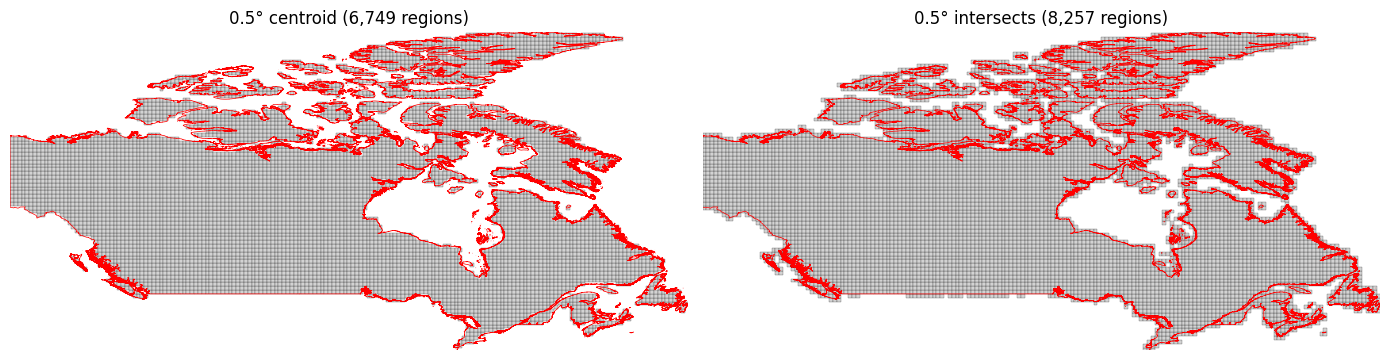

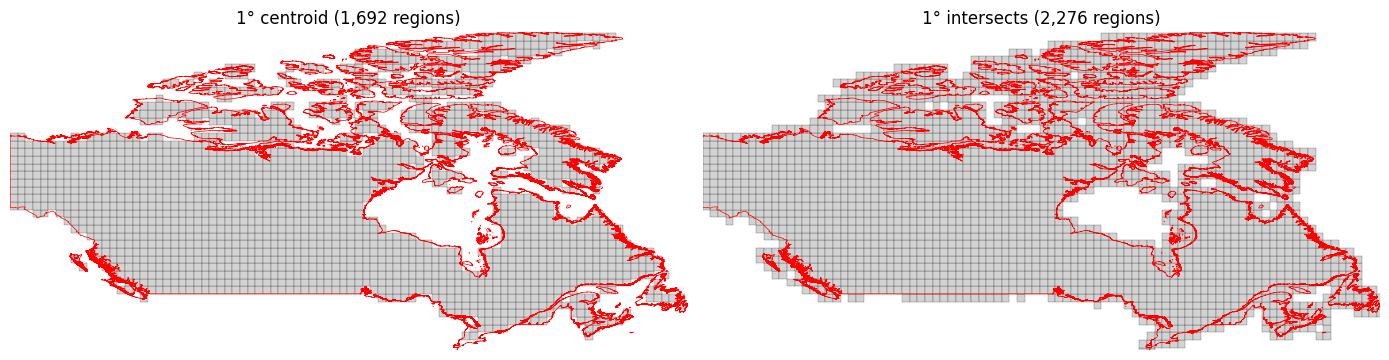

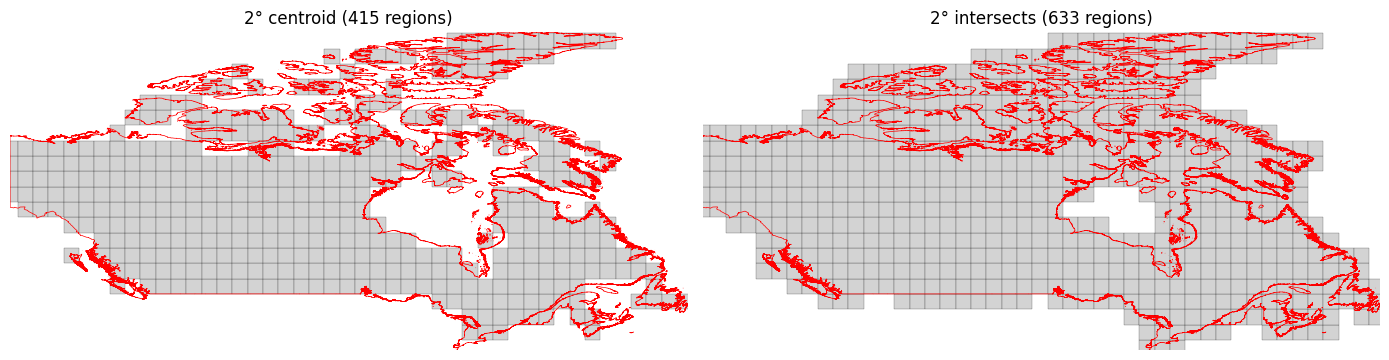

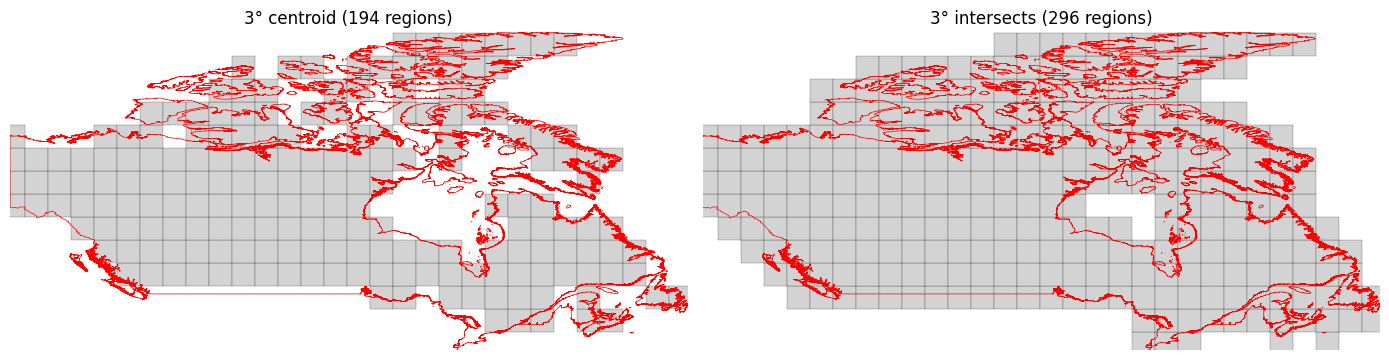

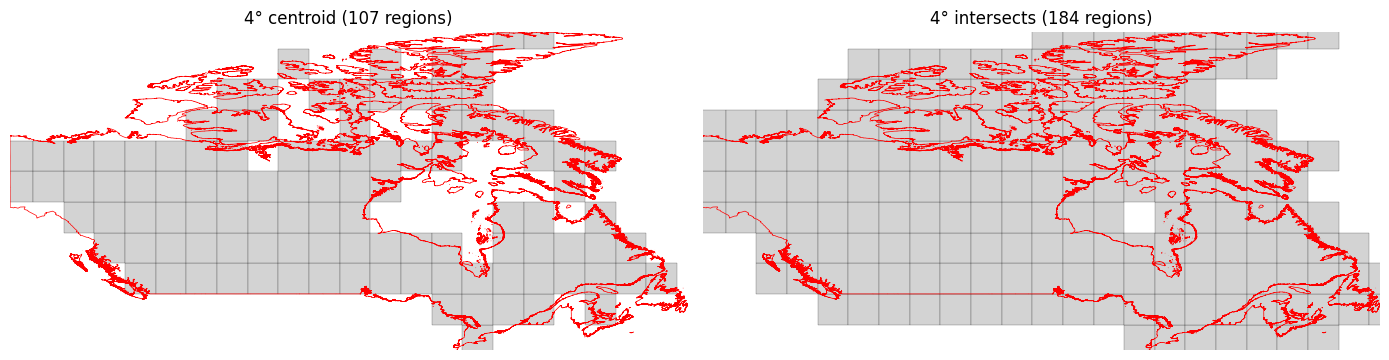

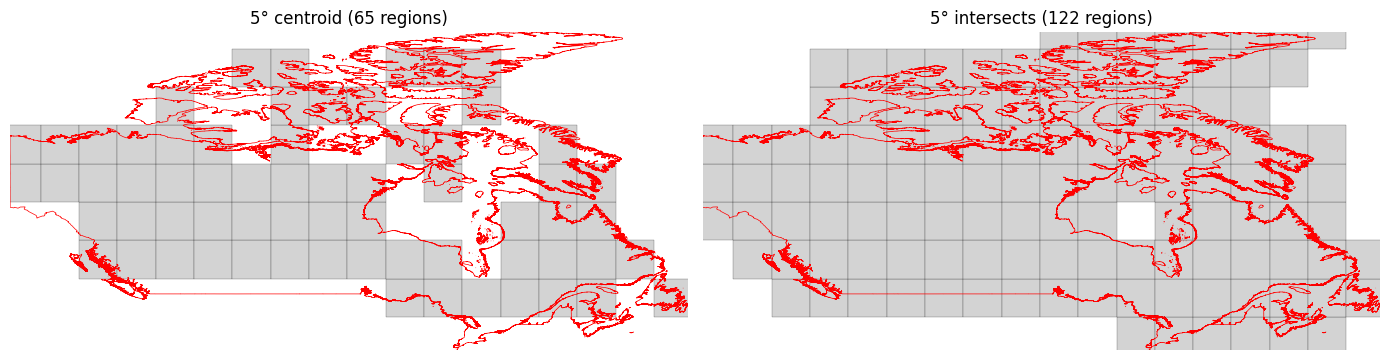

In [14]:
# Plot all basemap variants for comparison.

minx, miny, maxx, maxy = canada_boundary.total_bounds

for resolution_deg in BASEMAP_RESOLUTIONS:

    fig, axes = plt.subplots(
        ncols=2,
        figsize=(14, 8),
    )

    axes = np.atleast_1d(axes)

    for ax, keep_method in zip(axes, KEEP_METHODS):

        key = f"{resolution_deg:g}deg_{keep_method}"
        basemap = basemaps[key]

        basemap.plot(
            ax=ax,
            facecolor="lightgray",
            edgecolor="black",
            linewidth=0.15,
        )

        canada_boundary.boundary.plot(
            ax=ax,
            color="red",
            linewidth=0.5,
        )

        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect("equal")

        ax.set_title(
            f"{resolution_deg:g}° {keep_method} "
            f"({len(basemap):,} regions)"
        )

        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [15]:
# Export all basemap variants.

for key, basemap in basemaps.items():

    output_path = (
        PROCESSED_BASEMAP
        / f"canada_basemap_{key}.gpkg"
    )

    basemap.to_file(
        output_path,
        layer="regions",
        driver="GPKG",
    )

    print(
        f"Exported: {output_path.name}"
        f" ({len(basemap):,} regions)"
    )

basemap_summary.to_csv(
    PROCESSED_BASEMAP / "canada_basemap_summary.csv",
    index=False,
)

print("Exported: canada_basemap_summary.csv")

Exported: canada_basemap_0.5deg_centroid.gpkg (6,749 regions)
Exported: canada_basemap_0.5deg_intersects.gpkg (8,257 regions)
Exported: canada_basemap_1deg_centroid.gpkg (1,692 regions)
Exported: canada_basemap_1deg_intersects.gpkg (2,276 regions)
Exported: canada_basemap_2deg_centroid.gpkg (415 regions)
Exported: canada_basemap_2deg_intersects.gpkg (633 regions)
Exported: canada_basemap_3deg_centroid.gpkg (194 regions)
Exported: canada_basemap_3deg_intersects.gpkg (296 regions)
Exported: canada_basemap_4deg_centroid.gpkg (107 regions)
Exported: canada_basemap_4deg_intersects.gpkg (184 regions)
Exported: canada_basemap_5deg_centroid.gpkg (65 regions)
Exported: canada_basemap_5deg_intersects.gpkg (122 regions)
Exported: canada_basemap_summary.csv
